In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.inspection import DecisionBoundaryDisplay
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.tree import plot_tree

In [10]:
# Load the iris dataset
dataset = load_iris()
x = dataset.data
y = dataset.target
feature_names = dataset.feature_names
target_names = dataset.target_names

In [11]:
# Split into training and test set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [12]:
# Create and train the Gradient Boosting Classifier
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(x_train, y_train)

GradientBoostingClassifier(random_state=42)

In [13]:
# Predict and evaluate
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 1.00


In [14]:
# 1. PCA for decision boundary visualization
pca = PCA(n_components=2)
x_reduced = pca.fit_transform(x)
x_train_reduced = pca.transform(x_train)
x_test_reduced = pca.transform(x_test)

In [15]:
model_reduced = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model_reduced.fit(x_train_reduced, y_train)

GradientBoostingClassifier(random_state=42)

Text(0.5, 1.0, 'Decision Boundary after PCA')

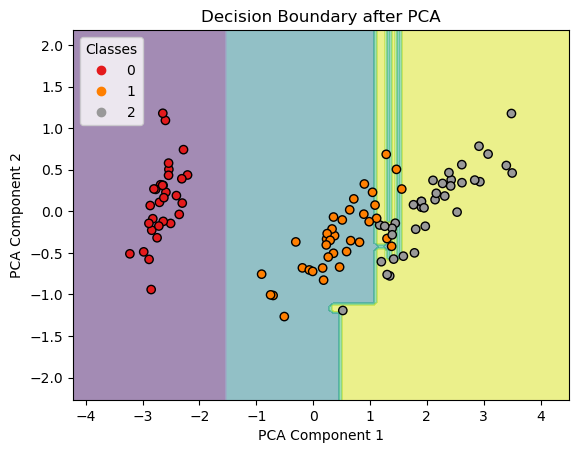

In [25]:
fig, ax = plt.subplots()
DecisionBoundaryDisplay.from_estimator(
    model_reduced,
    x_train_reduced,
    response_method="predict",
    xlabel="PCA Component 1",
    ylabel="PCA Component 2",
    alpha=0.5,
    ax=ax,
)
scatter = ax.scatter(x_train_reduced[:, 0], x_train_reduced[:, 1], c=y_train, edgecolor='k', cmap=plt.cm.Set1)
legend = ax.legend(*scatter.legend_elements(), title="Classes")
plt.title("Decision Boundary after PCA")

Text(0.5, 1.0, 'Confusion Matrix')

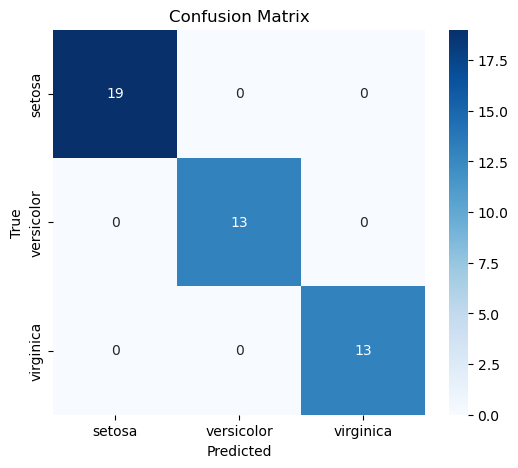

In [26]:
# 2. Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

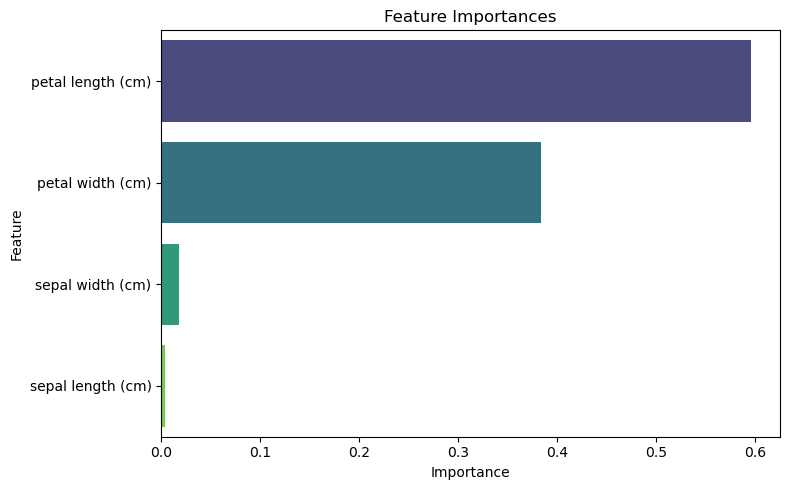

In [29]:
# 3. Feature Importances
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], hue=np.array(feature_names)[indices], palette="viridis")
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

In [ ]:
first_tree = model.estimators_[0, 0]  # (stage, class)

plt.figure(figsize=(16, 10))
plot_tree(first_tree, filled=True, feature_names=feature_names, class_names=target_names)
plt.title("First Tree in Gradient Boosting Ensemble")

In [ ]:
tree_depths = [est[0].get_depth() for est in model.estimators_]
tree_leaves = [est[0].get_n_leaves() for est in model.estimators_]

plt.figure(figsize=(10, 5))
plt.plot(tree_depths, label="Tree depth")
plt.plot(tree_leaves, label="Number of leaves")
plt.xlabel("Estimator index")
plt.ylabel("Value")
plt.legend()
plt.title("Tree Depth and Number of Leaves per Estimator")
plt.grid(True)